In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error

In [2]:
# Load datasets
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

train.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [3]:
# Select target and drop non necessary variables
X = train.drop(columns=["Rings"])
y = train["Rings"]

test_ids = test["id"]

X = X.drop(columns=["id"])
test_clean = test.drop(columns=["id"])

In [4]:
# Train validation split
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Lasso regression pipeline L1
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_log_error

categorical_features = ["Sex"]
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

lasso_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.001, max_iter=10000, random_state=42))
    ]
)

In [6]:
# Train Lasso Model
lasso_model.fit(X_train, np.log1p(y_train))

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex']),
                                                 ('num', StandardScaler(),
                                                  ['Length', 'Diameter',
                                                   'Height', 'Whole weight',
                                                   'Whole weight.1',
                                                   'Whole weight.2',
                                                   'Shell weight'])])),
                ('model', Lasso(alpha=0.001, max_iter=10000, random_state=42))])

In [7]:
# Model Validation
valid_preds_log = lasso_model.predict(X_valid)
valid_preds = np.expm1(valid_preds_log)

valid_preds = np.clip(valid_preds, 1, None)

rmsle = np.sqrt(mean_squared_log_error(y_valid, valid_preds))

print("Lasso RMSLE:", rmsle)

Lasso RMSLE: 0.1671971468663894


In [8]:
# View Selected Features
onehot_names = lasso_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

feature_names = list(onehot_names) + numeric_features

coefficients = lasso_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute Coefficient": abs(coefficients)
}).sort_values(by="Absolute Coefficient", ascending=False)

coef_df

,Feature,Coefficient,Absolute Coefficient
7,Whole weight.1,-0.209794,0.209794
9,Shell weight,0.203198,0.203198
4,Diameter,0.103663,0.103663
5,Height,0.073312,0.073312
1,Sex_I,-0.060847,0.060847
3,Length,0.032874,0.032874
8,Whole weight.2,-0.013809,0.013809
0,Sex_F,0.000000,0.000000
2,Sex_M,0.000000,0.000000
6,Whole weight,0.000000,0.000000


In [9]:
# Predict on Test dataset
test_preds_log = lasso_model.predict(test_clean)
test_preds = np.expm1(test_preds_log)

test_preds = np.clip(test_preds, 1, None)

In [10]:
# Kaggle submissionfile
submission = pd.DataFrame({
    "id": test_ids,
    "Rings": test_preds
})

submission.to_csv("lasso_submission.csv", index=False)

submission.head()

,id,Rings
0,90615,9.113327
1,90616,10.091827
2,90617,10.024371
3,90618,10.914567
4,90619,7.544966


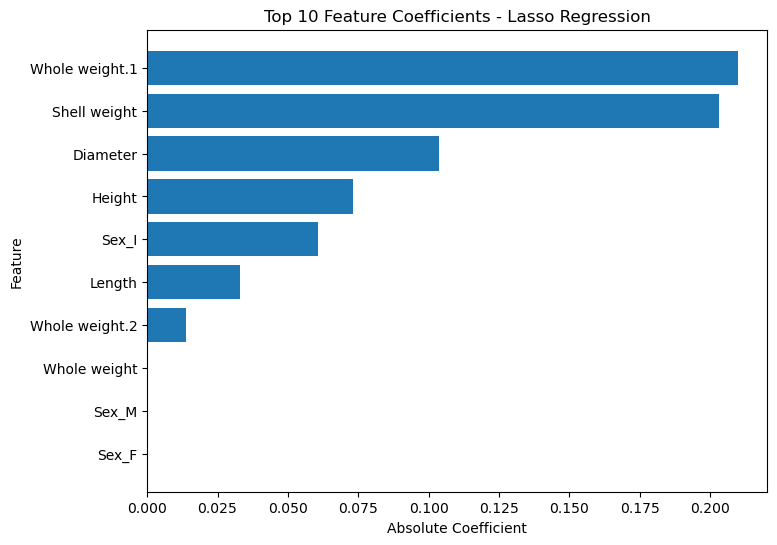

In [11]:
# Coefficient Importance
import matplotlib.pyplot as plt

top_coef = coef_df.head(10).sort_values("Absolute Coefficient")

plt.figure(figsize=(8, 6))
plt.barh(top_coef["Feature"], top_coef["Absolute Coefficient"])
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Feature Coefficients - Lasso Regression")
plt.show()

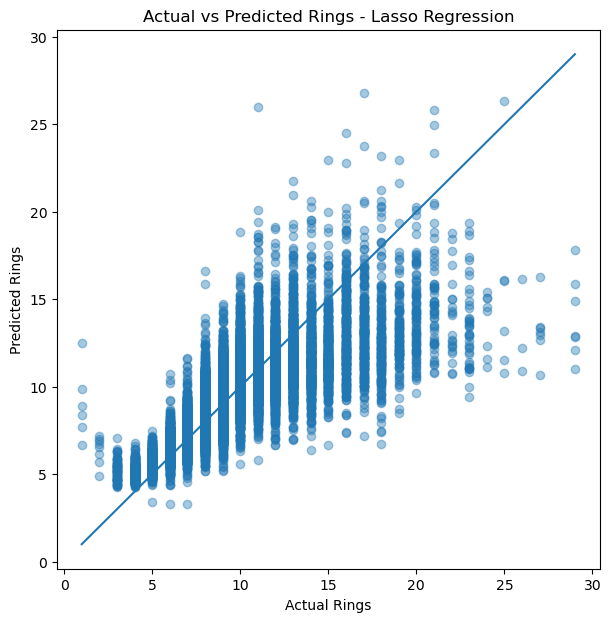

In [12]:
# Actual Vs Predicted Chart
plt.figure(figsize=(7, 7))
plt.scatter(y_valid, valid_preds, alpha=0.4)
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs Predicted Rings - Lasso Regression")
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()])
plt.show()